In [22]:
!pip install -q wandb

In [23]:
#import wandb

#wandb.login()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [25]:
#import wandb
from wandb.integration.keras import WandbMetricsLogger

In [26]:
import pandas as pd
url = "https://raw.githubusercontent.com/brayandiazlievano-11/CienciaDeDatosModulo4/main/global_house_purchase_dataset.csv"
df = pd.read_csv(url)
df.head()

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


In [27]:
df.shape

(200000, 25)

In [28]:
df.columns

Index(['property_id', 'country', 'city', 'property_type', 'furnishing_status',
       'property_size_sqft', 'price', 'constructed_year', 'previous_owners',
       'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported',
       'legal_cases_on_property', 'customer_salary', 'loan_amount',
       'loan_tenure_years', 'monthly_expenses', 'down_payment',
       'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating',
       'connectivity_score', 'decision'],
      dtype='object')

In [29]:
df.head()

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   property_id              200000 non-null  int64  
 1   country                  200000 non-null  object 
 2   city                     200000 non-null  object 
 3   property_type            200000 non-null  object 
 4   furnishing_status        200000 non-null  object 
 5   property_size_sqft       200000 non-null  int64  
 6   price                    200000 non-null  int64  
 7   constructed_year         200000 non-null  int64  
 8   previous_owners          200000 non-null  int64  
 9   rooms                    200000 non-null  int64  
 10  bathrooms                200000 non-null  int64  
 11  garage                   200000 non-null  int64  
 12  garden                   200000 non-null  int64  
 13  crime_cases_reported     200000 non-null  int64  
 14  lega

In [31]:
df.describe(include='all')

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
count,200000.000000,200000,200000,200000,200000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,...,200000.000000,2.000000e+05,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
unique,NaN,13,40,6,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Singapore,Farmhouse,Fully-Furnished,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,15628,15278,33518,66829,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,100000.500000,NaN,NaN,NaN,NaN,3195.633460,1.215365e+06,1991.487770,3.001370,4.513855,...,46528.625830,7.597583e+05,19.986375,10559.693105,4.556068e+05,0.195387,5.498650,5.505240,5.495615,0.230340
std,57735.171256,NaN,NaN,NaN,NaN,1613.322287,8.236633e+05,18.494064,2.002198,2.295669,...,27997.353766,5.489401e+05,7.081080,5427.241879,3.629865e+05,0.219689,2.875361,2.870945,2.870206,0.421052
min,1.000000,NaN,NaN,NaN,NaN,400.000000,5.628800e+04,1960.000000,0.000000,1.000000,...,2000.000000,2.350400e+04,10.000000,500.000000,8.966000e+03,0.000000,1.000000,1.000000,1.000000,0.000000
25%,50000.750000,NaN,NaN,NaN,NaN,1802.000000,5.659895e+05,1975.000000,1.000000,3.000000,...,21450.000000,3.372802e+05,15.000000,5770.000000,1.849592e+05,0.070000,3.000000,3.000000,3.000000,0.000000
50%,100000.500000,NaN,NaN,NaN,NaN,3190.000000,1.023429e+06,1991.000000,3.000000,5.000000,...,41465.000000,6.269325e+05,20.000000,10520.000000,3.561700e+05,0.130000,5.000000,5.000000,5.000000,0.000000
75%,150000.250000,NaN,NaN,NaN,NaN,4589.000000,1.725556e+06,2008.000000,5.000000,7.000000,...,70805.000000,1.058416e+06,25.000000,15260.000000,6.257352e+05,0.240000,8.000000,8.000000,8.000000,0.000000


In [32]:
print(df.columns.tolist())

['property_id', 'country', 'city', 'property_type', 'furnishing_status', 'property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score', 'decision']


In [33]:
X = df.drop("decision", axis=1)
y = df["decision"]

In [34]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Convertir también la variable objetivo
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160000, 24)
(40000, 24)
(160000,)
(40000,)


In [40]:
"""wandb.init(
    project="house-purchase-rna",
    name="entrenamiento_1",
    config={
        "epochs":20,
        "batch_size":32,
        "optimizer":"adam",
        "architecture":"64-32-16"
    }
)"""

'wandb.init(\n    project="house-purchase-rna",\n    name="entrenamiento_1",\n    config={\n        "epochs":20,\n        "batch_size":32,\n        "optimizer":"adam",\n        "architecture":"64-32-16"\n    }\n)'

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    #callbacks=[WandbMetricsLogger()],
    verbose=1
)

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9765 - loss: 0.0547 - val_accuracy: 0.9965 - val_loss: 0.0077
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9977 - loss: 0.0054 - val_accuracy: 0.9981 - val_loss: 0.0044
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9983 - loss: 0.0042 - val_accuracy: 0.9984 - val_loss: 0.0037
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9983 - loss: 0.0045 - val_accuracy: 0.9984 - val_loss: 0.0035
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9988 - loss: 0.0030 - val_accuracy: 0.9985 - val_loss: 0.0033
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 0.9979 - val_loss: 0.0051
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9989 - loss: 0.0028 - val_accuracy: 0.9978 - val_loss: 0.0056
Epoch 8/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9990 - loss: 0

In [45]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3391 - loss: 0.7728
Loss: 0.7728440761566162
Accuracy: 0.3390749990940094


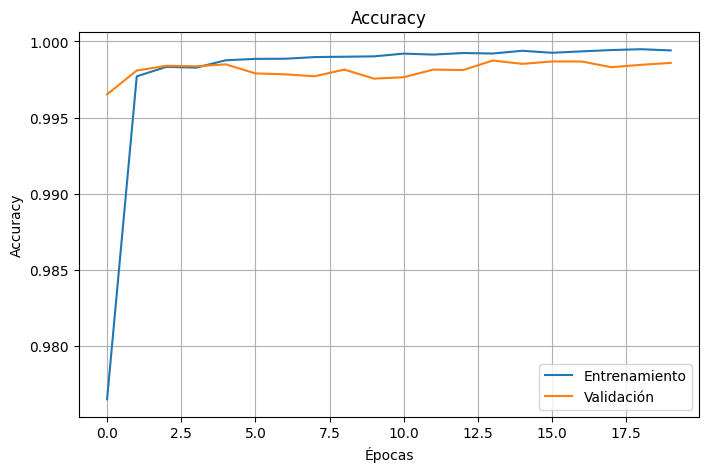

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

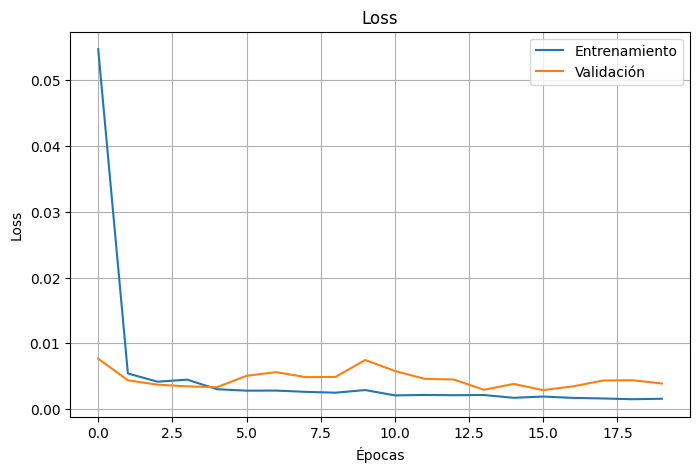

In [52]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Entrenamiento 2**

In [55]:
# entrenmiento 2

"""wandb.init(
    project="house-purchase-rna",
    name="entrenamiento_2",
    config={
        "epochs":30,
        "batch_size":32,
        "optimizer":"adam",
        "architecture":"64-32-16"
    }
)
"""
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    #callbacks=[WandbMetricsLogger()],
    verbose=1
)

loss2, accuracy2 = model.evaluate(X_test, y_test)

print("Loss:", loss2)
print("Accuracy:", accuracy2)

wandb.finish()

Epoch 1/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9805 - loss: 0.0458 - val_accuracy: 0.9977 - val_loss: 0.0058
Epoch 2/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9978 - loss: 0.0055 - val_accuracy: 0.9980 - val_loss: 0.0046
Epoch 3/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9981 - loss: 0.0043 - val_accuracy: 0.9983 - val_loss: 0.0034
Epoch 4/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9985 - loss: 0.0039 - val_accuracy: 0.9984 - val_loss: 0.0031
Epoch 5/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9987 - loss: 0.0033 - val_accuracy: 0.9986 - val_loss: 0.0036
Epoch 6/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9989 - loss: 0.0029 - val_accuracy: 0.9985 - val_loss: 0.0035
Epoch 7/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9989 - loss: 0.0027 - val_accuracy: 0.9982 - val_loss: 0.0041
Epoch 8/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9990 - loss: 0

**Entrenamiento 3**

In [56]:
# entrenamiento 3

"""wandb.init(
    project="house-purchase-rna",
    name="entrenamiento_3",
    config={
        "epochs":20,
        "batch_size":64,
        "optimizer":"adam",
        "architecture":"128-64-32"
    }
)"""

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    #callbacks=[WandbMetricsLogger()],
    verbose=1
)

loss3, accuracy3 = model.evaluate(X_test, y_test)

print("Loss:", loss3)
print("Accuracy:", accuracy3)

#wandb.finish()

Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9803 - loss: 0.0473 - val_accuracy: 0.9975 - val_loss: 0.0059
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9978 - loss: 0.0055 - val_accuracy: 0.9979 - val_loss: 0.0045
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9981 - loss: 0.0053 - val_accuracy: 0.9977 - val_loss: 0.0056
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9983 - loss: 0.0042 - val_accuracy: 0.9987 - val_loss: 0.0032
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9987 - loss: 0.0032 - val_accuracy: 0.9985 - val_loss: 0.0040
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9987 - loss: 0.0032 - val_accuracy: 0.9990 - val_loss: 0.0025
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9988 - loss: 0.0027 - val_accuracy: 0.9987 - val_loss: 0.0033
Epoch 8/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9990 - loss: 0.0028 - 

In [ ]:
#wandb.finish()